In [6]:
# tf dataset의 cat/dog 이미지 분류 + 전이학습 + 미세조정 : 결과 보다는 과정을 이해!!!
# 백본 : MobileNet V2
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

# tfds.disable_progress_bar()     # 진행률 표시바 비활성화
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,   # dict type으로 반환
)
print(raw_train)
print(raw_validation)
print(raw_test)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.QJG2P5_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [7]:
total = metadata.splits['train'].num_examples
print('train 전체  수 : ', total)
print('raw_train 수 : ', int(total * 0.8))
print('raw_vali 수 : ', int(total * 0.1))
print('raw_test 수 : ', int(total * 0.1))




train 전체  수 :  23262
raw_train 수 :  18609
raw_vali 수 :  2326
raw_test 수 :  2326


dog
원본 1개: (262, 350, 3) 1


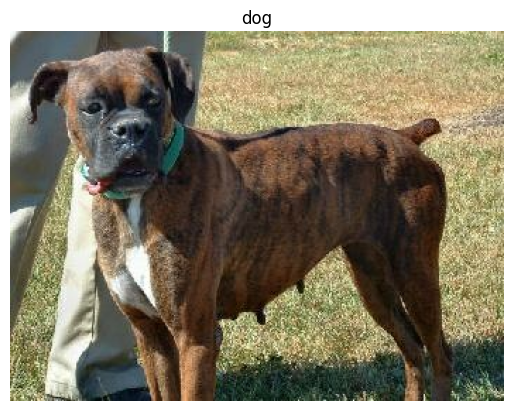

In [8]:
# label명 얻기
get_label__name = metadata.features['label'].int2str
print(get_label__name(1))

# 샘플 자료 보기
for image, label in raw_train.take(1):
  print('원본 1개:', image.shape, label.numpy())  # (262, 350, 3) 1
  plt.figure()
  plt.imshow(image)
  plt.title(get_label__name(label))
  plt.axis('off')
  plt.show()


In [9]:
# 전처리 함수 - cat/dog 크기가 다양함. 크기 고정, 정규화
IMG_SIZE = 160

def format_examleFunc(image, label):
  image = tf.cast(image, tf.float32)    # unit - > float32
  image = (image/127.5) - 1.0           # [0.255] ->-1
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  return image, label

# 원본 dataset을 전처리된 dataset으로 변경
# tf.data.AUTOTUNE : 여러 개의 샘플을 병렬로 자동 처리(CPU 코어수, 리소스 자원 관리 등)

train = raw_train.map(format_examleFunc, num_parallel_calls=tf.data.AUTOTUNE)
validation = raw_validation.map(format_examleFunc, num_parallel_calls=tf.data.AUTOTUNE)
test = raw_test.map(format_examleFunc, num_parallel_calls=tf.data.AUTOTUNE)

# 전처리 검증
for img, label in train.take(1):
  print('전처리 샘플 dtype : ', img.dtype)
  print('전처리 샘플 shape : ', img.shape)
  print('min/max:', float(tf.reduce_min(img)), float(tf.reduce_max(img)))

# batch pipeline 운영
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

# train만 shuffle함, 나머지 둘은 고정. 1000개의 샘플을 메모리에 로딩해서 섞음
# prefetch : 모델이 학습하는 동ㅇㄴ 다음 학습에 필요한 데이터를 미리 가져와 전처리해
train_batches = (train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
validation_batches = (validation.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
test_batches = (test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# 아래 코드 참고용 : batch x
for image_single, label_single in raw_train.take(1):
  print('원본 단일 이미지 shape : ', label_single.numpy().shape)
  print('라벨 :', label_single.numpy())


전처리 샘플 dtype :  <dtype: 'float32'>
전처리 샘플 shape :  (160, 160, 3)
min/max: -1.0 1.0
원본 단일 이미지 shape :  ()
라벨 : 1


In [10]:
# base model
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,      # 분류기 뺌(왜냐하면 개,고양이를 분류)
    weights='imagenet'
)
print(base_model.summary())

# 전처리/배치가 된 텐서를 통과시켜 특정 맵 얻기
images_batch, label_batch = next(iter(train_batches))
feature_batch = base_model(images_batch)
print('입력 배치 shape : ', images_batch.shape)   # (32, 160, 160, 3)
print('특징 배치 shape : ', feature_batch.shape)  #  (32, 5, 5, 1280) 하나의 이미지는 (5, 5, 1280)

gloval_avg = tf.keras.layers.GlobalAveragePooling2D()(feature_batch)
print('GAP 후 shape : ', gloval_avg.shape)
# (32, 1280) : 5 * 5를 평균내고 채널 축만 남김(1280차 벡터 하나로 요약)
# 배치 크기는 유지하면서 최종 shape:(32, 1280)을 측만 남기면 이미지 당 한개의 고정길이 벡터를 얻어
# Dense(분류기)에 넣기 쉬워진다.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

None
입력 배치 shape :  (32, 160, 160, 3)
특징 배치 shape :  (32, 5, 5, 1280)
GAP 후 shape :  (32, 1280)


In [ ]:
from tensorflow.python.training.saver import metrics
# 모델 정의
# Sequential로 정의
# model = tf.keras.Sequential([
#     tf.keras.layers.input(shape=IMG_SHAPE),
#     base_model,
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(units=1, activation='sigmoid')  # base_model + 이진분류기
# ])

# Functional로 정의
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(units=1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
# print(model.summary())

base_model.trainable =False   # 특징 추출기(Conv + Pooling) 동결

model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=10
)

loss, acc = model.evaluate(test_batches ,verbose=0)
print(f'loss :{loss:.4f}, acc : {acc:.4f}')


Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 477s 805ms/step - accuracy: 0.9737 - loss: 0.0747 - val_accuracy: 0.9828 - val_loss: 0.0482
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 509s 869ms/step - accuracy: 0.9841 - loss: 0.0443 - val_accuracy: 0.9862 - val_loss: 0.0431
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.9854 - loss: 0.0392 - val_accuracy: 0.9862 - val_loss: 0.0414
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 511s 872ms/step - accuracy: 0.9869 - loss: 0.0356 - val_accuracy: 0.9854 - val_loss: 0.0411
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 453s 776ms/step - accuracy: 0.9883 - loss: 0.0332 - val_accuracy: 0.9832 - val_loss: 0.0439
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 459s 786ms/step - accuracy: 0.9896 - loss: 0.0304 - val_accuracy: 0.9850 - val_loss: 0.0434
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 472s 804ms/step - accuracy: 0.9905 - loss: 0.0277 - val_accuracy: 0.9837 - val_loss: 0.0452
Epoch 8/10
321/582 ━━━━━━━━━━━━━━━━━━━━ 3:05 709ms/step - accuracy: 0.9921 - lo

In [ ]:
# 성능 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
# Fine Tunning(미세조정) 적용하기
base_model.trainable = True   # 특징 추출기(Conv + Pooling) 동결 해제
fine_tune_at = 100     # MobileNetV2 레이어 150개 중 50개만 학습에 참여

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Checkpoint, EarlyStopping
os.makedirs('checkpoint', exist_ok=True)
ckpt_path_ft = "checkpoint/finetune_best.keras"

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft,
        monitor='val_accuracy',
        mode ='max',
        save_best_only=True,
        verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(   # val_loss 개선이 멈추면 learning_rate를 0.5qo wnfdla
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=0
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]


In [ ]:
EPOCHS_TRANSFER = 10    # 전이학습에서 이미 10회 학습함
EPOCHS_FINETUNE = 10    # 미세조정에서 추가학습할 epoch 수

history_ft = model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=EPOCHS_TRANSFER + EPOCHS_FINETUNE,
    initial_epoch=history.epoch[-1],
    callbacks=callbacks_ft,
    verbose= 2
)

loss, acc = model.evaluate(test_batches, verbose=0)
print(f'loss :{loss:.4f}, acc : {acc:.4f}')